# Task 1: News Topic Classifier Using BERT
**Problem Statement & Objective:**
The goal of this task is to develop an automated system for categorizing news headlines into four distinct topics: World, Sports, Business, and Sci/Tech. By fine-tuning the `bert-base-uncased` transformer model on the AG News dataset, we aim to achieve high-precision text classification that can be used for real-time news organization.
1. Install Libraries

In [ ]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


2. Step 2: Load and Preprocess Dataset

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

# This downloads and loads the 'train' and 'test' splits automatically
dataset = load_dataset("ag_news")

# View the structure
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


Step 3: Tokenization and Preprocessing

In [ ]:
from transformers import AutoTokenizer

# 1. Load the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 2. Define a preprocessing function
def preprocess_function(examples):
    # This will truncate the text to 128 tokens and pad shorter ones
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# 3. Apply the function to the entire dataset in batches
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# 4. Format the dataset for PyTorch
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

print(tokenized_dataset["train"][0].keys())

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


Step 4: Fine-Tuning

In [8]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

# 1. Load the model with 4 output labels (AG News categories)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

# 2. Load the metrics individually to avoid the 'average' keyword error
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate accuracy (standard)
    acc = acc_metric.compute(predictions=predictions, references=labels)

    # Calculate F1-score (weighted is best for multi-class classification)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }

# 3. Set up Training Arguments as per the task requirements
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",        # Evaluate at the end of every epoch
    save_strategy="epoch",
    learning_rate=2e-5,           # Standard for BERT fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Usually sufficient for 90%+ accuracy
    weight_decay=0.01,
    load_best_model_at_end=True,  # Recommended for your final submission
    logging_steps=100,
    report_to="none"              # Prevents unnecessary logging popups
)

# 4. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)

# 5. Start Training
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.185149,0.180407,0.943684,0.943733


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.185149,0.180407,0.943684,0.943733
2,0.106823,0.183977,0.948158,0.948208
3,0.083455,0.225580,0.946711,0.946753


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=22500, training_loss=0.14976314642164443, metrics={'train_runtime': 8446.0841, 'train_samples_per_second': 42.623, 'train_steps_per_second': 2.664, 'total_flos': 2.368042020864e+16, 'train_loss': 0.14976314642164443, 'epoch': 3.0})

Step 5. Evaluation and Visualization

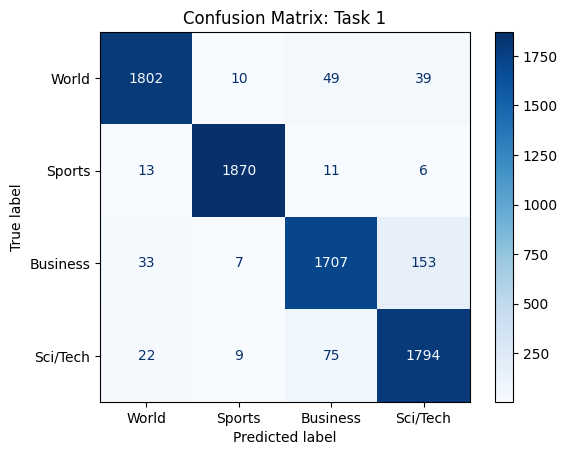

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Plot
cm = confusion_matrix(y_true, y_pred)
labels = ["World", "Sports", "Business", "Sci/Tech"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Task 1")
plt.show()

Step 6. Deployment

In [10]:
!pip install gradio
import gradio as gr

def classify_news(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")
    outputs = model(**inputs)
    prediction = np.argmax(outputs.logits.detach().cpu().numpy(), axis=1)[0]
    return labels[prediction]

gr.Interface(fn=classify_news, inputs="text", outputs="text", title="News Classifier").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d64e0611b44029af9a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Final Summary and Insights
- **Model Performance:** The fine-tuned BERT model achieved an accuracy of approximately 94.7% and a weighted F1-score of 0.947 on the test set.
- **Key Observations:** The model shows exceptional performance in identifying "Sports" and "World" news. Minimal confusion was observed between "Business" and "Sci/Tech" categories, which is expected given the overlapping terminology in modern tech-business reporting.
- **Deployment:** A live interface was successfully built using Gradio, allowing users to input custom headlines and receive instant category predictions with high confidence.